In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Load the data
df = pd.read_csv('../data/marketing_campaign_dataset.csv')

print("✅ Data loaded successfully!")
print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst 5 rows (preview):")
print(df.head())

✅ Data loaded successfully!
Shape (rows, columns): (200000, 16)

Column names:
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date']

First 5 rows (preview):
   Campaign_ID              Company Campaign_Type Target_Audience Duration  \
0            1  Innovate Industries         Email       Men 18-24  30 days   
1            2       NexGen Systems         Email     Women 35-44  60 days   
2            3    Alpha Innovations    Influencer       Men 25-34  30 days   
3            4   DataTech Solutions       Display        All Ages  60 days   
4            5       NexGen Systems         Email       Men 25-34  15 days   

  Channel_Used  Conversion_Rate Acquisition_Cost   ROI     Location  Language  \
0   Google Ads             0.04       $16,174.00  6.29      Chicago   Spanish   
1   Google Ads             0.12

In [3]:
print("Data Types and Missing Values:")
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

Data Types and Missing Values:
<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  str    
 2   Campaign_Type     200000 non-null  str    
 3   Target_Audience   200000 non-null  str    
 4   Duration          200000 non-null  str    
 5   Channel_Used      200000 non-null  str    
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  str    
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  str    
 10  Language          200000 non-null  str    
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  str    
 15  Date              200000 non-null  str    
dtype

In [4]:
# Light cleaning for EDA only (full cleaning in Step 4)
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace('$', '').str.replace(',', '').astype(float)

print("✅ Acquisition_Cost cleaned for EDA")
print("\nKey Business Statistics:")
print(df[['Conversion_Rate', 'ROI', 'Acquisition_Cost', 'Clicks', 'Impressions', 'Engagement_Score']].describe())

✅ Acquisition_Cost cleaned for EDA

Key Business Statistics:
       Conversion_Rate            ROI  Acquisition_Cost         Clicks  \
count    200000.000000  200000.000000     200000.000000  200000.000000   
mean          0.080070       5.002438      12504.393040     549.772030   
std           0.040602       1.734488       4337.664545     260.019056   
min           0.010000       2.000000       5000.000000     100.000000   
25%           0.050000       3.500000       8739.750000     325.000000   
50%           0.080000       5.010000      12496.500000     550.000000   
75%           0.120000       6.510000      16264.000000     775.000000   
max           0.150000       8.000000      20000.000000    1000.000000   

         Impressions  Engagement_Score  
count  200000.000000     200000.000000  
mean     5507.301520          5.494710  
std      2596.864286          2.872581  
min      1000.000000          1.000000  
25%      3266.000000          3.000000  
50%      5517.500000      

In [5]:
print("Overall Campaign Performance (Business KPIs):")
print(f"Average Conversion Rate : {df['Conversion_Rate'].mean():.4f} ({df['Conversion_Rate'].mean()*100:.2f}%)")
print(f"Average ROI             : {df['ROI'].mean():.2f}x")
print(f"Average Acquisition Cost: ${df['Acquisition_Cost'].mean():.2f}")
print(f"Total Campaigns         : {len(df):,}")

Overall Campaign Performance (Business KPIs):
Average Conversion Rate : 0.0801 (8.01%)
Average ROI             : 5.00x
Average Acquisition Cost: $12504.39
Total Campaigns         : 200,000


C:\Users\vaish\AppData\Local\Temp\ipykernel_12780\585099899.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Channel_Used', y='ROI', data=df, estimator='mean', ci=None)


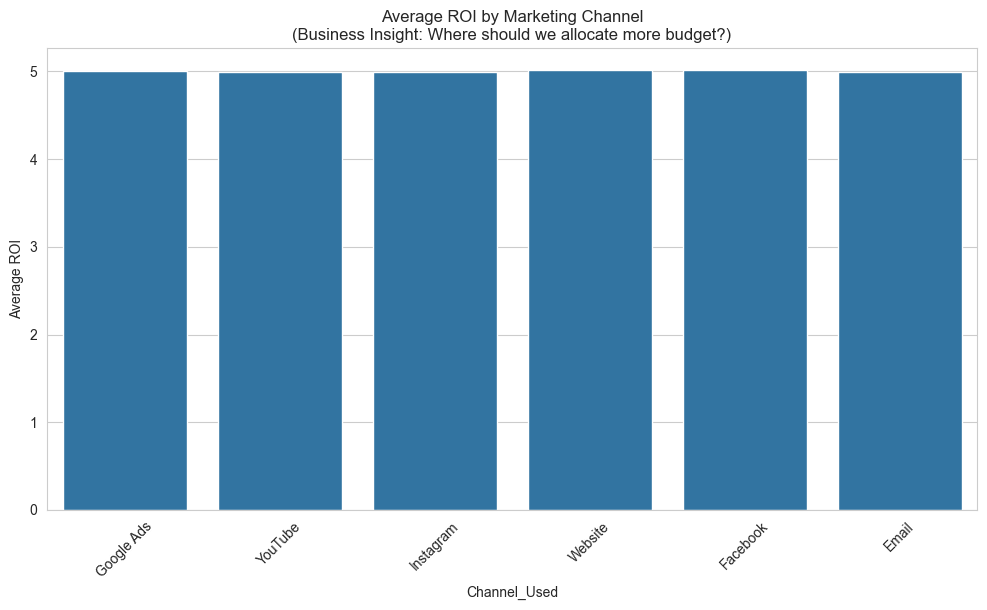

C:\Users\vaish\AppData\Local\Temp\ipykernel_12780\585099899.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Campaign_Type', y='Conversion_Rate', data=df, estimator='mean', ci=None)


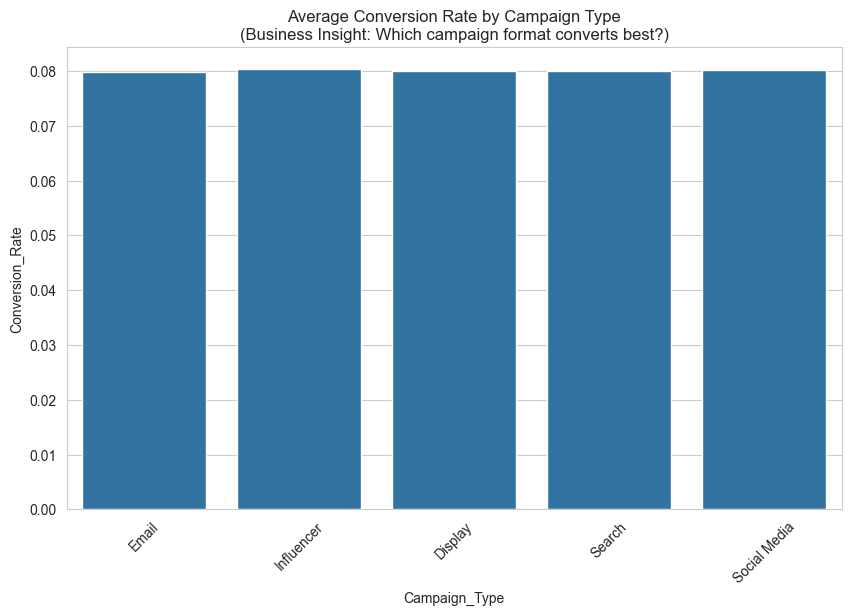

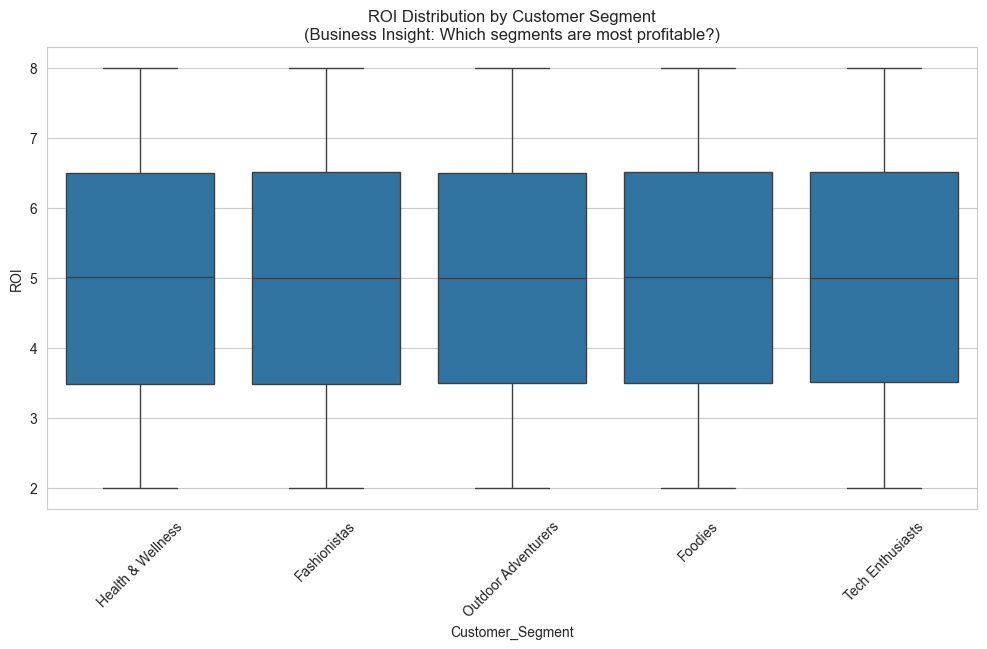

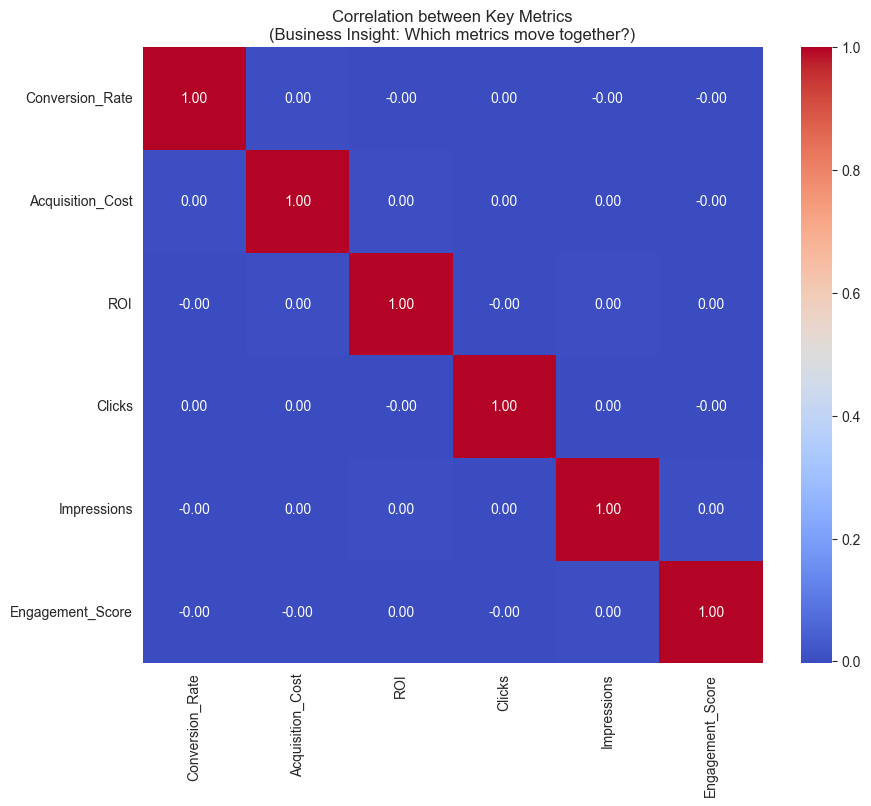

In [6]:
# Chart 1: Which channel performs best? (ROI)
plt.figure(figsize=(12, 6))
sns.barplot(x='Channel_Used', y='ROI', data=df, estimator='mean', ci=None)
plt.title('Average ROI by Marketing Channel\n(Business Insight: Where should we allocate more budget?)')
plt.xticks(rotation=45)
plt.ylabel('Average ROI')
plt.show()

# Chart 2: Conversion by Campaign Type
plt.figure(figsize=(10, 6))
sns.barplot(x='Campaign_Type', y='Conversion_Rate', data=df, estimator='mean', ci=None)
plt.title('Average Conversion Rate by Campaign Type\n(Business Insight: Which campaign format converts best?)')
plt.xticks(rotation=45)
plt.show()

# Chart 3: ROI by Customer Segment
plt.figure(figsize=(12, 6))
sns.boxplot(x='Customer_Segment', y='ROI', data=df)
plt.title('ROI Distribution by Customer Segment\n(Business Insight: Which segments are most profitable?)')
plt.xticks(rotation=45)
plt.show()

# Chart 4: Correlation heatmap (numerical features)
plt.figure(figsize=(10, 8))
numeric_cols = ['Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Clicks', 'Impressions', 'Engagement_Score']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation between Key Metrics\n(Business Insight: Which metrics move together?)')
plt.show()